# 🇮🇳 India Trade Analysis (2010–2025)
### Graphical Analysis of India's Import & Export Relationships with Top 10 Countries
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

IMPORT_PALETTE = sns.color_palette('tab10', 10)
EXPORT_PALETTE = sns.color_palette('Set2', 10)

In [2]:
# ── Load & clean data ──────────────────────────────────────────────────────────
raw = pd.read_excel('IMPORT_EXPORT.xlsx', sheet_name='Sheet1', header=None)

import_countries = ['CHINA','UAE','RUSSIA','ARAB','SWITZERLAND','IRAQ','UK','USA','INDONESIA','SINGAPORE']
export_countries = ['USA','UAE','NETHERLANDS','CHINA','BANGLADESH','UK','SINGAPORE','ARAB','AUSTRALIA','GERMANY']

years = []
for v in raw.iloc[2:, 0]:
    try:
        years.append(pd.to_datetime(v).year)
    except:
        years.append(int(str(v)[:4]))

imp_df = pd.DataFrame(
    raw.iloc[2:, 1:11].values.astype(float),
    index=years, columns=import_countries
)
imp_df.index.name = 'Year'

exp_df = pd.DataFrame(
    raw.iloc[2:, 11:21].values.astype(float),
    index=years, columns=export_countries
)
exp_df.index.name = 'Year'

# Divide by 1e6 to convert to Trillion INR for better readability
imp_T = imp_df / 1e6
exp_T = exp_df / 1e6

print("✅ Data loaded successfully!")
print(f"   Years: {min(years)} – {max(years)}")
print(f"   Import countries: {import_countries}")
print(f"   Export countries: {export_countries}")

✅ Data loaded successfully!
   Years: 2010 – 2025
   Import countries: ['CHINA', 'UAE', 'RUSSIA', 'ARAB', 'SWITZERLAND', 'IRAQ', 'UK', 'USA', 'INDONESIA', 'SINGAPORE']
   Export countries: ['USA', 'UAE', 'NETHERLANDS', 'CHINA', 'BANGLADESH', 'UK', 'SINGAPORE', 'ARAB', 'AUSTRALIA', 'GERMANY']


---
## 📊 Plot 1 — India's Total Imports by Country Over 16 Years (Line Chart)

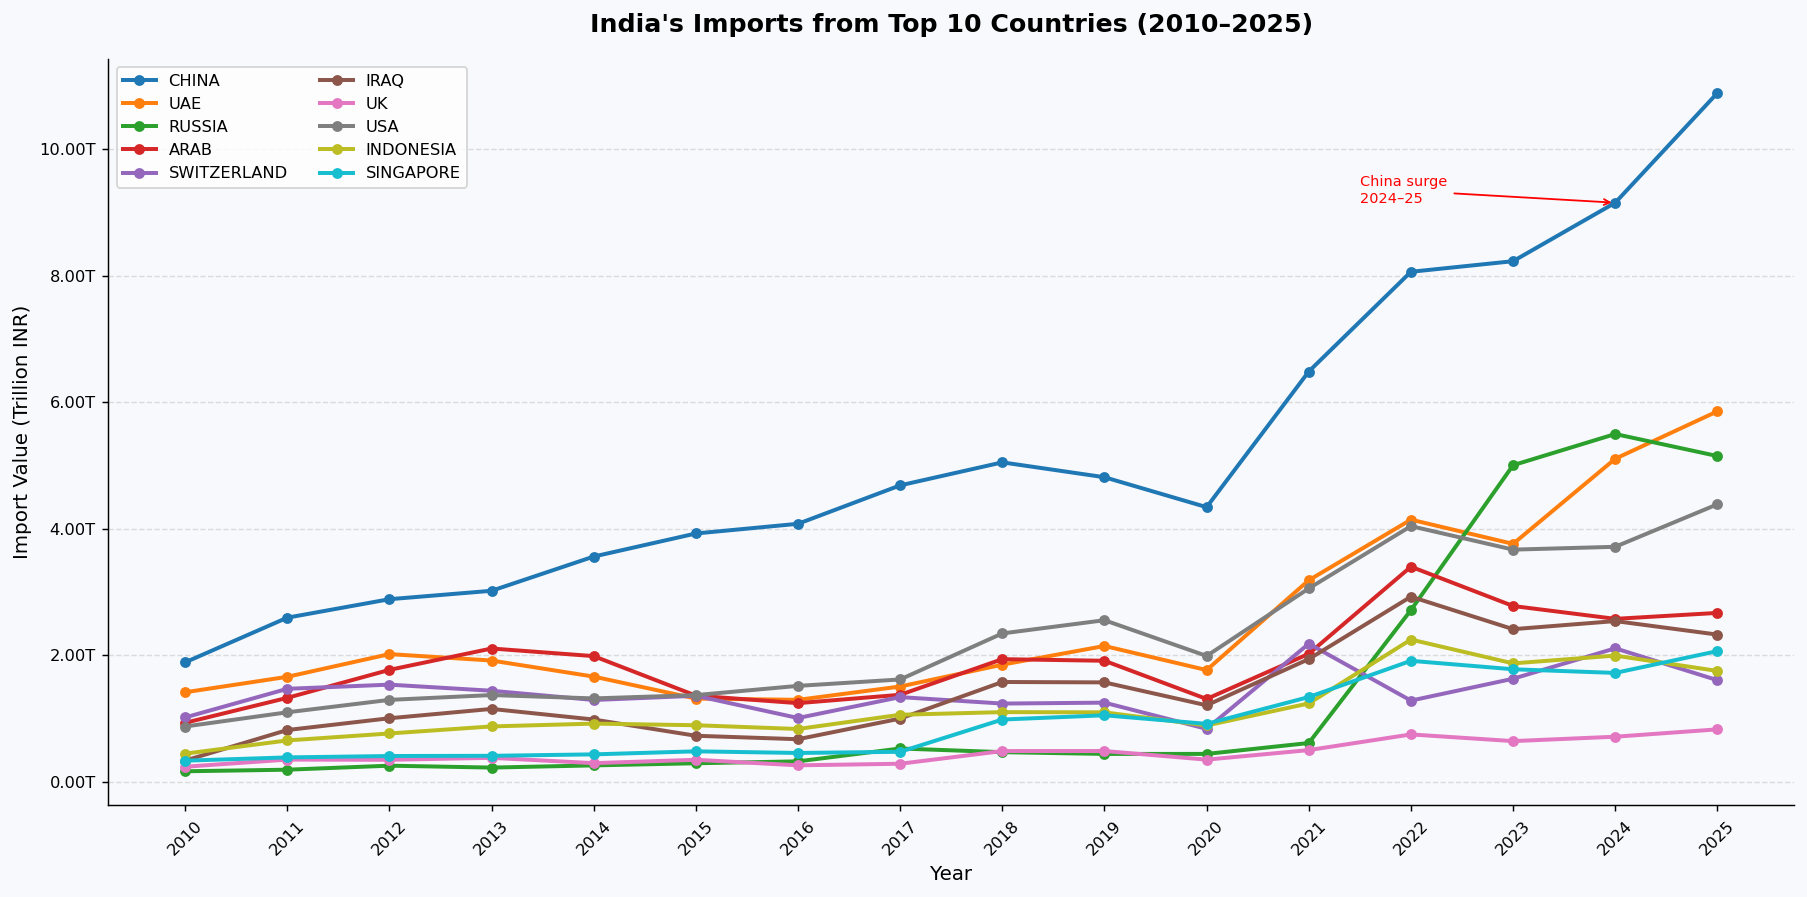


🔍 Conclusion: China consistently dominates India's imports, growing nearly 6x from 2010 to 2025.
UAE and Saudi Arabia (ARAB) are also significant. Russia shows a dramatic spike in 2022–23 likely due to energy re-routing post Ukraine war.


In [3]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('#f7f9fc')

for i, country in enumerate(import_countries):
    ax.plot(imp_T.index, imp_T[country], marker='o', markersize=5,
            linewidth=2.2, color=IMPORT_PALETTE[i], label=country)

ax.set_title("India's Imports from Top 10 Countries (2010–2025)", pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Import Value (Trillion INR)")
ax.set_xticks(imp_T.index)
ax.set_xticklabels(imp_T.index, rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}T'))
ax.legend(loc='upper left', fontsize=9, framealpha=0.8, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Annotate China's spike in 2024–25
ax.annotate('China surge\n2024–25', xy=(2024, imp_T.loc[2024,'CHINA']),
            xytext=(2021.5, imp_T.loc[2024,'CHINA']+0.002),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')

plt.tight_layout()
plt.savefig('plot1_imports_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: China consistently dominates India's imports, growing nearly 6x from 2010 to 2025.\nUAE and Saudi Arabia (ARAB) are also significant. Russia shows a dramatic spike in 2022–23 likely due to energy re-routing post Ukraine war.")

---
## 📊 Plot 2 — India's Total Exports by Country Over 16 Years (Line Chart)

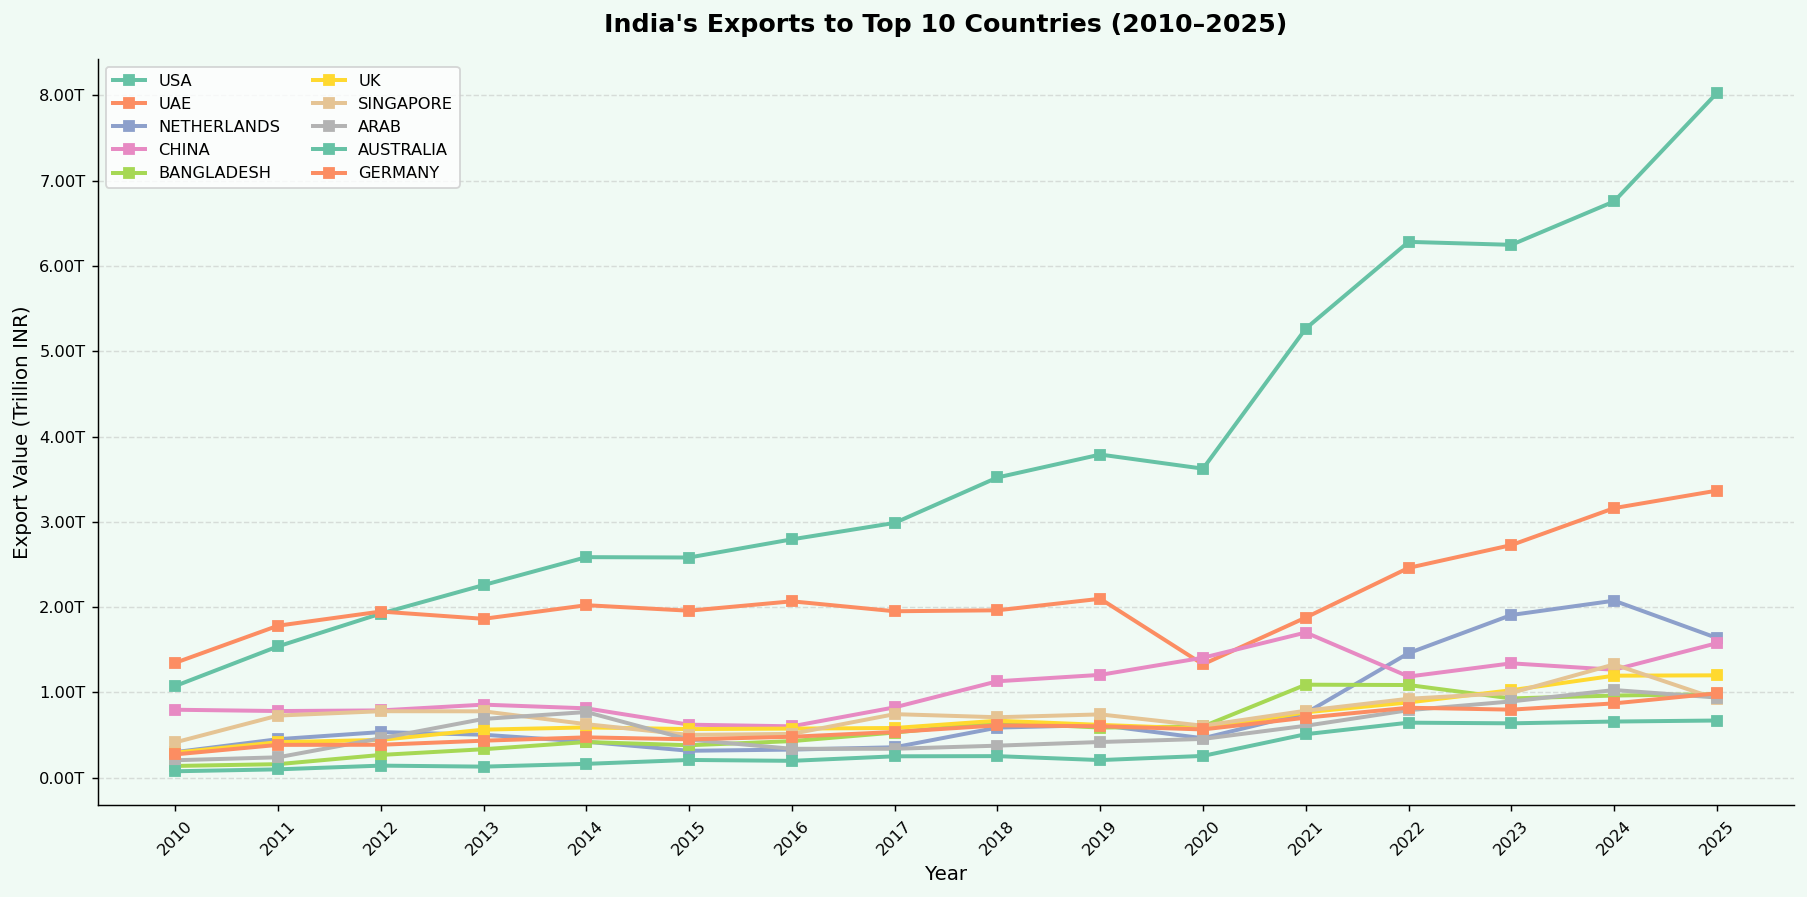


🔍 Conclusion: USA is the top export destination for India, followed by UAE and Netherlands.
Exports have grown steadily, especially post-2020, reflecting India's growing manufacturing and service exports.


In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#f0faf4')
ax.set_facecolor('#f0faf4')

for i, country in enumerate(export_countries):
    ax.plot(exp_T.index, exp_T[country], marker='s', markersize=5,
            linewidth=2.2, color=EXPORT_PALETTE[i], label=country)

ax.set_title("India's Exports to Top 10 Countries (2010–2025)", pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (Trillion INR)")
ax.set_xticks(exp_T.index)
ax.set_xticklabels(exp_T.index, rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}T'))
ax.legend(loc='upper left', fontsize=9, framealpha=0.8, ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot2_exports_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: USA is the top export destination for India, followed by UAE and Netherlands.\nExports have grown steadily, especially post-2020, reflecting India's growing manufacturing and service exports.")

---
## 📊 Plot 3 — Pie Chart: Average Import Share by Country (2010–2025)

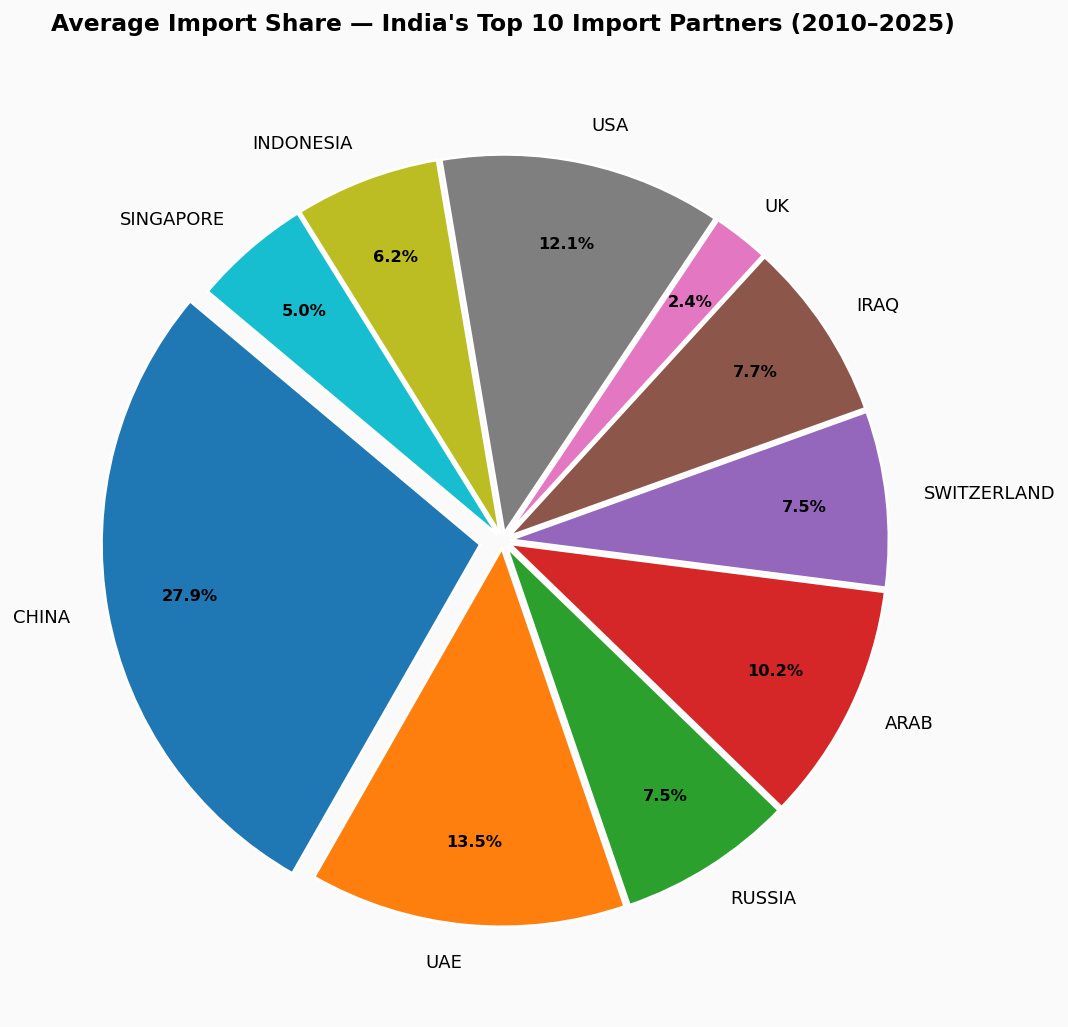


🔍 Conclusion: China accounts for ~27.9% of India's total imports from top-10 partners on average — a clear dominance that highlights significant trade dependency.


In [5]:
avg_imp = imp_T.mean()
explode = [0.06 if c == 'CHINA' else 0.02 for c in import_countries]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#fafafa')
wedges, texts, autotexts = ax.pie(
    avg_imp, labels=import_countries, autopct='%1.1f%%',
    colors=IMPORT_PALETTE, explode=explode,
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title("Average Import Share — India's Top 10 Import Partners (2010–2025)",
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('plot3_import_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🔍 Conclusion: China accounts for ~{avg_imp['CHINA']/avg_imp.sum()*100:.1f}% of India's total imports from top-10 partners on average — a clear dominance that highlights significant trade dependency.")

---
## 📊 Plot 4 — Pie Chart: Average Export Share by Country (2010–2025)

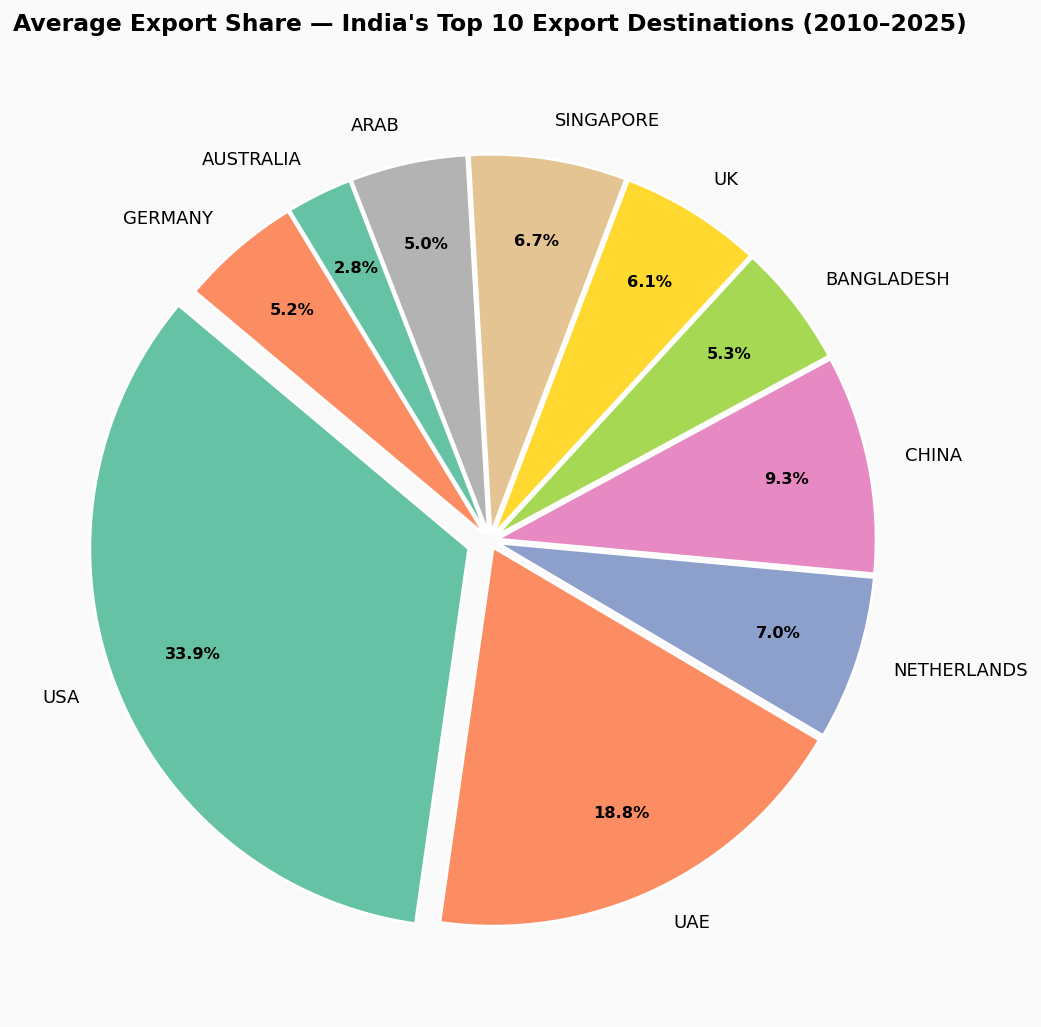


🔍 Conclusion: USA leads India's export destinations at ~33.9%, followed by UAE and Netherlands. The export basket is more diversified than imports.


In [6]:
avg_exp = exp_T.mean()
explode_e = [0.06 if c == 'USA' else 0.02 for c in export_countries]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#fafafa')
wedges, texts, autotexts = ax.pie(
    avg_exp, labels=export_countries, autopct='%1.1f%%',
    colors=EXPORT_PALETTE, explode=explode_e,
    startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title("Average Export Share — India's Top 10 Export Destinations (2010–2025)",
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('plot4_export_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🔍 Conclusion: USA leads India's export destinations at ~{avg_exp['USA']/avg_exp.sum()*100:.1f}%, followed by UAE and Netherlands. The export basket is more diversified than imports.")

---
## 📊 Plot 5 — Trade Deficit per Country: Total 16-Year Cumulative

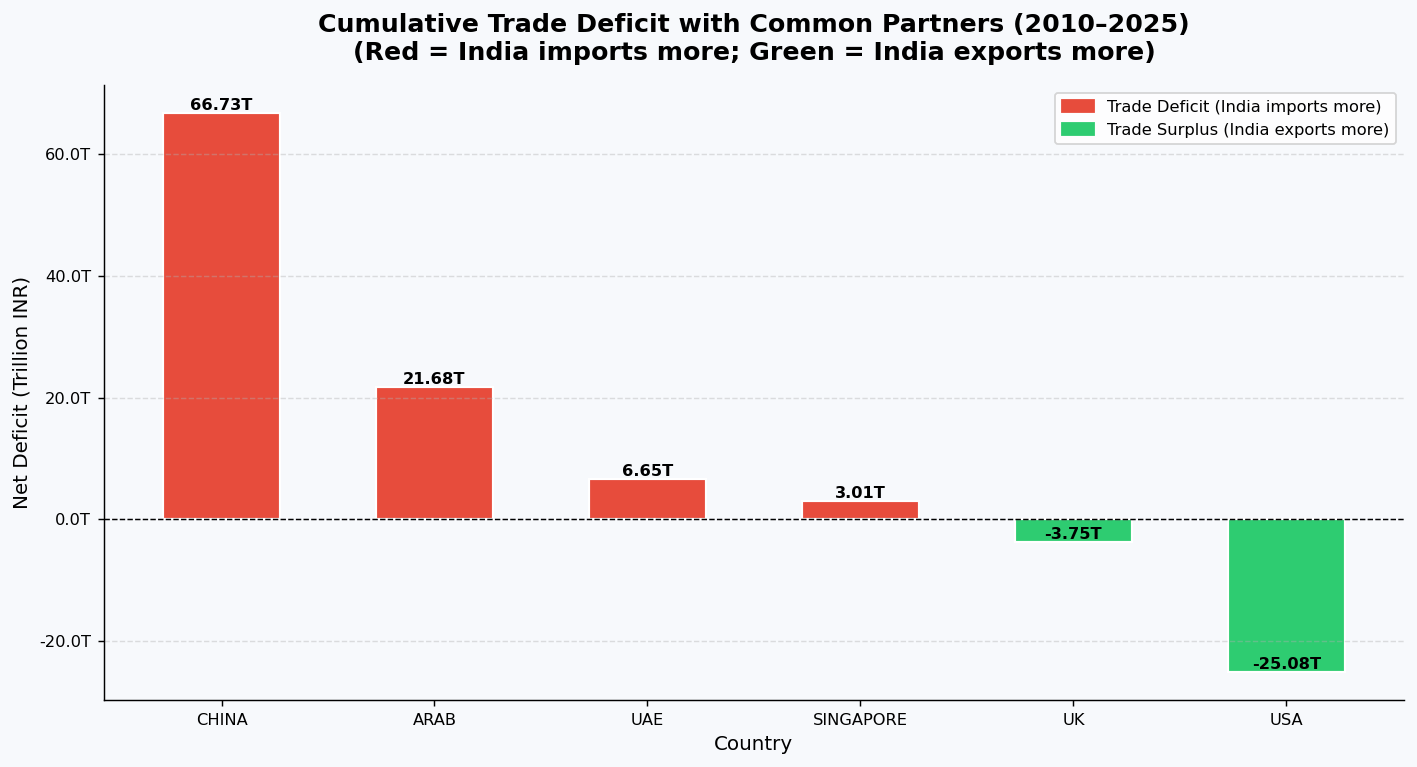


🔍 Conclusion:
  CHINA       : DEFICIT of 66.73 Trillion INR over 16 years
  ARAB        : DEFICIT of 21.68 Trillion INR over 16 years
  UAE         : DEFICIT of 6.65 Trillion INR over 16 years
  SINGAPORE   : DEFICIT of 3.01 Trillion INR over 16 years
  UK          : SURPLUS of 3.75 Trillion INR over 16 years
  USA         : SURPLUS of 25.08 Trillion INR over 16 years


In [7]:
# Countries that appear in BOTH lists
common = ['CHINA', 'UAE', 'USA', 'UK', 'SINGAPORE', 'ARAB']

# Fix column name mismatch
exp_T_renamed = exp_T.rename(columns={'NETHERLANDS': 'NETHARLAND', 'INDONESIA': 'INDONASIA'})

deficit = {}
for c in common:
    total_imp = imp_T[c].sum()
    exp_col = c
    if exp_col not in exp_T.columns:
        continue
    total_exp = exp_T[exp_col].sum()
    deficit[c] = total_imp - total_exp  # positive = India imports more (deficit)

deficit_df = pd.Series(deficit).sort_values(ascending=False)
colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in deficit_df.values]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('#f7f9fc')
bars = ax.bar(deficit_df.index, deficit_df.values, color=colors_bar, edgecolor='white',
              linewidth=1.2, width=0.55)

for bar, val in zip(bars, deficit_df.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}T', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Cumulative Trade Deficit with Common Partners (2010–2025)\n(Red = India imports more; Green = India exports more)",
             pad=14)
ax.set_ylabel("Net Deficit (Trillion INR)")
ax.set_xlabel("Country")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}T'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

red_patch = mpatches.Patch(color='#e74c3c', label='Trade Deficit (India imports more)')
green_patch = mpatches.Patch(color='#2ecc71', label='Trade Surplus (India exports more)')
ax.legend(handles=[red_patch, green_patch], fontsize=9)

plt.tight_layout()
plt.savefig('plot5_trade_deficit.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Conclusion:")
for c, v in deficit_df.items():
    status = 'DEFICIT' if v > 0 else 'SURPLUS'
    print(f"  {c:<12}: {status} of {abs(v):.2f} Trillion INR over 16 years")

---
## 📊 Plot 6 — Stacked Bar: Year-wise Total Import & Export Volume

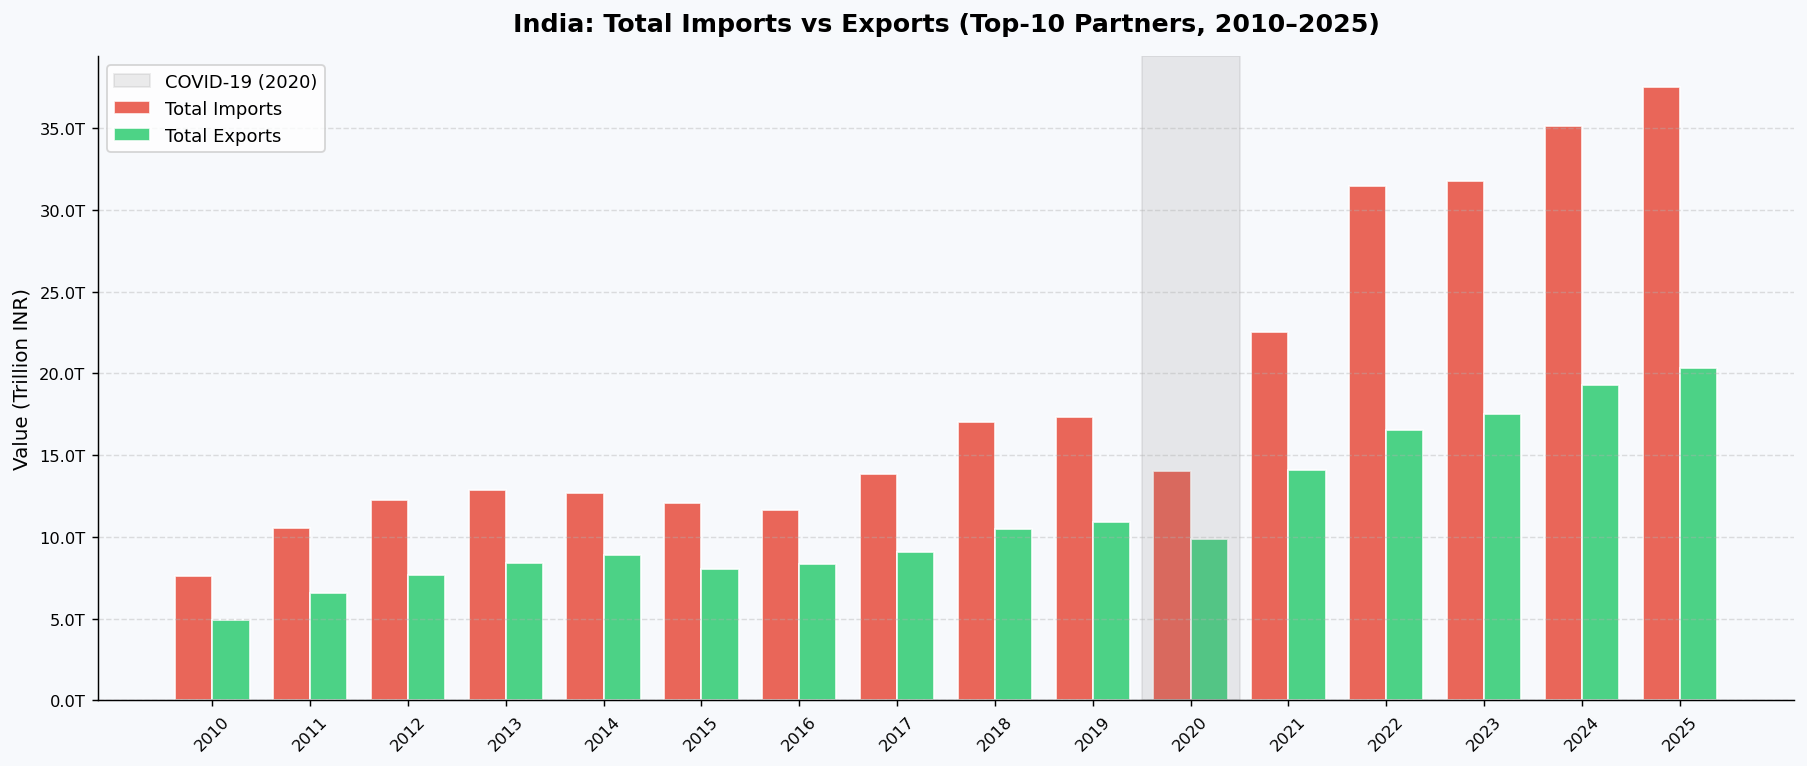


🔍 Conclusion: Imports consistently exceed exports, confirming India's structural trade deficit.
The COVID-19 year (2020) shows a visible dip in both. The post-2021 surge reflects global commodity price increases.


In [8]:
total_imp_yearly = imp_T.sum(axis=1)
total_exp_yearly = exp_T.sum(axis=1)

x = np.arange(len(years))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('#f7f9fc')

b1 = ax.bar(x - width/2, total_imp_yearly.values, width, label='Total Imports',
            color='#e74c3c', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, total_exp_yearly.values, width, label='Total Exports',
            color='#2ecc71', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_title("India: Total Imports vs Exports (Top-10 Partners, 2010–2025)", pad=14)
ax.set_ylabel("Value (Trillion INR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}T'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Shade COVID year
ax.axvspan(x[years.index(2020)]-0.5, x[years.index(2020)]+0.5, alpha=0.15, color='gray', label='COVID-19 (2020)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('plot6_import_export_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: Imports consistently exceed exports, confirming India's structural trade deficit.\nThe COVID-19 year (2020) shows a visible dip in both. The post-2021 surge reflects global commodity price increases.")

---
## 📊 Plot 7 — Heatmap: Import Values by Country and Year

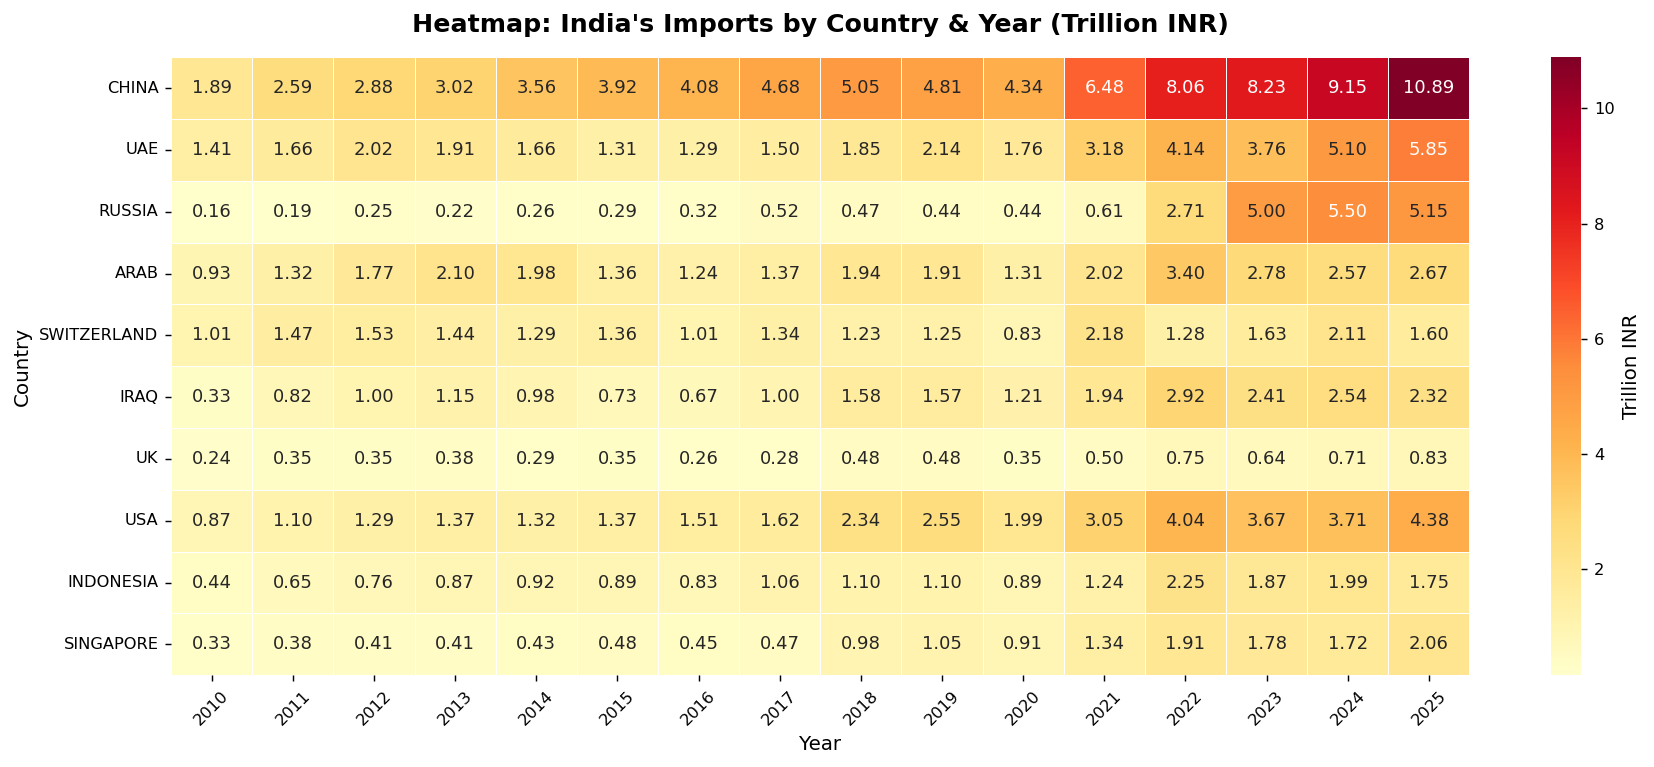


🔍 Conclusion: The heatmap clearly shows China (top row) getting progressively darker — imports almost tripling post-2020.
Russia shows a distinct heat spike in 2022–25 (energy imports surge). The map also reveals relatively stable imports from UK and Indonesia.


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')

sns.heatmap(
    imp_T.T, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Trillion INR'}
)
ax.set_title("Heatmap: India's Imports by Country & Year (Trillion INR)", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Country")
ax.set_xticklabels(imp_T.index, rotation=45)

plt.tight_layout()
plt.savefig('plot7_import_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: The heatmap clearly shows China (top row) getting progressively darker — imports almost tripling post-2020.\nRussia shows a distinct heat spike in 2022–25 (energy imports surge). The map also reveals relatively stable imports from UK and Indonesia.")

---
## 📊 Plot 8 — Heatmap: Export Values by Country and Year

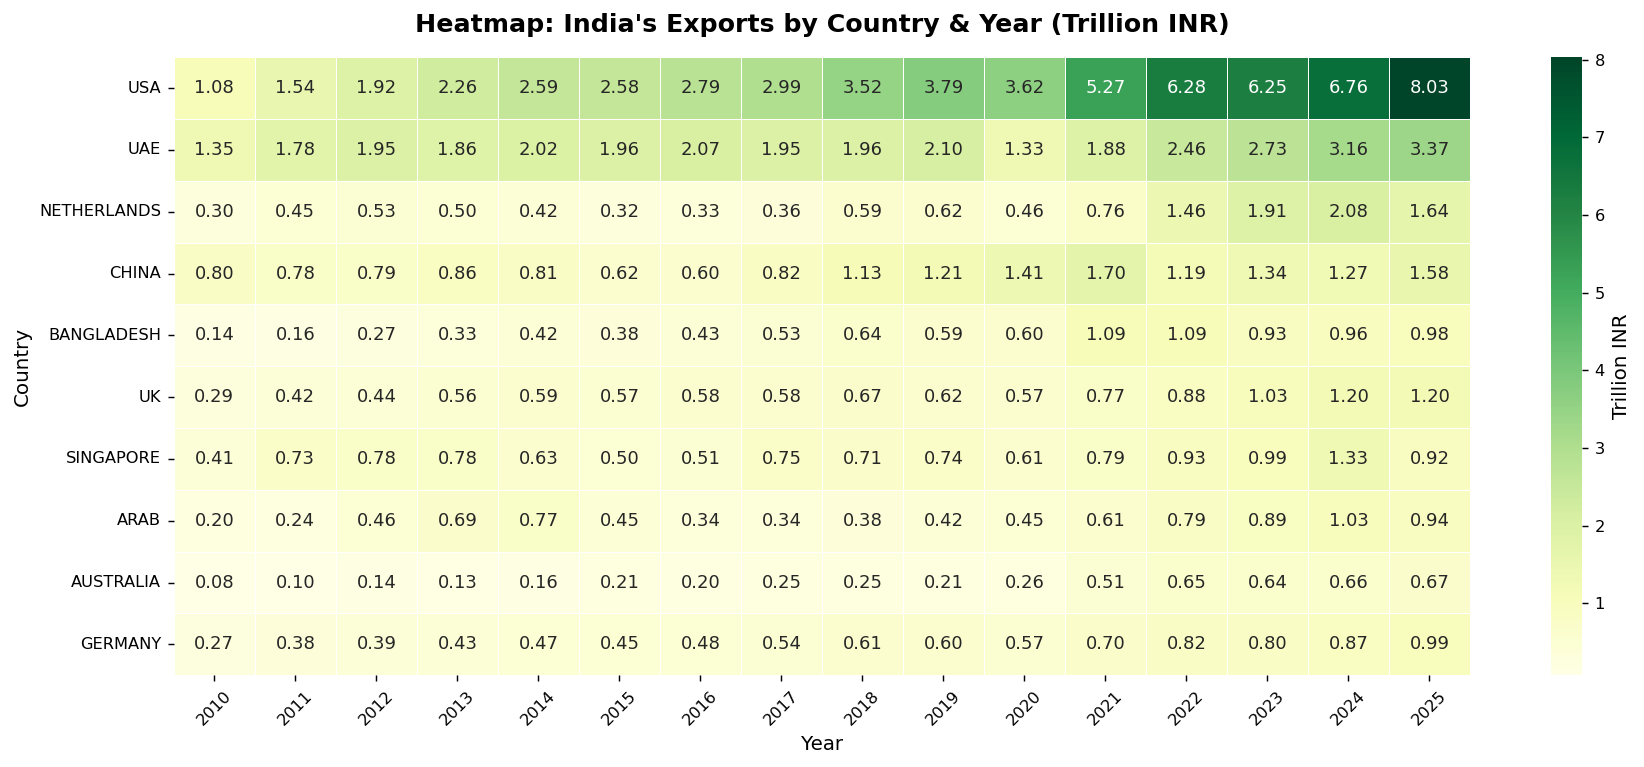


🔍 Conclusion: USA consistently shows strong export values. Netherlands (re-export hub) has been growing.
Bangladesh and Australia show moderate, steady growth. COVID-19 dip (2020) is visible across all countries.


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')

sns.heatmap(
    exp_T.T, annot=True, fmt='.2f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Trillion INR'}
)
ax.set_title("Heatmap: India's Exports by Country & Year (Trillion INR)", pad=14)
ax.set_xlabel("Year")
ax.set_ylabel("Country")
ax.set_xticklabels(exp_T.index, rotation=45)

plt.tight_layout()
plt.savefig('plot8_export_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: USA consistently shows strong export values. Netherlands (re-export hub) has been growing.\nBangladesh and Australia show moderate, steady growth. COVID-19 dip (2020) is visible across all countries.")

---
## 📊 Plot 9 — Comparative: Top 5 Import vs Export Partners (Side-by-Side Bars)

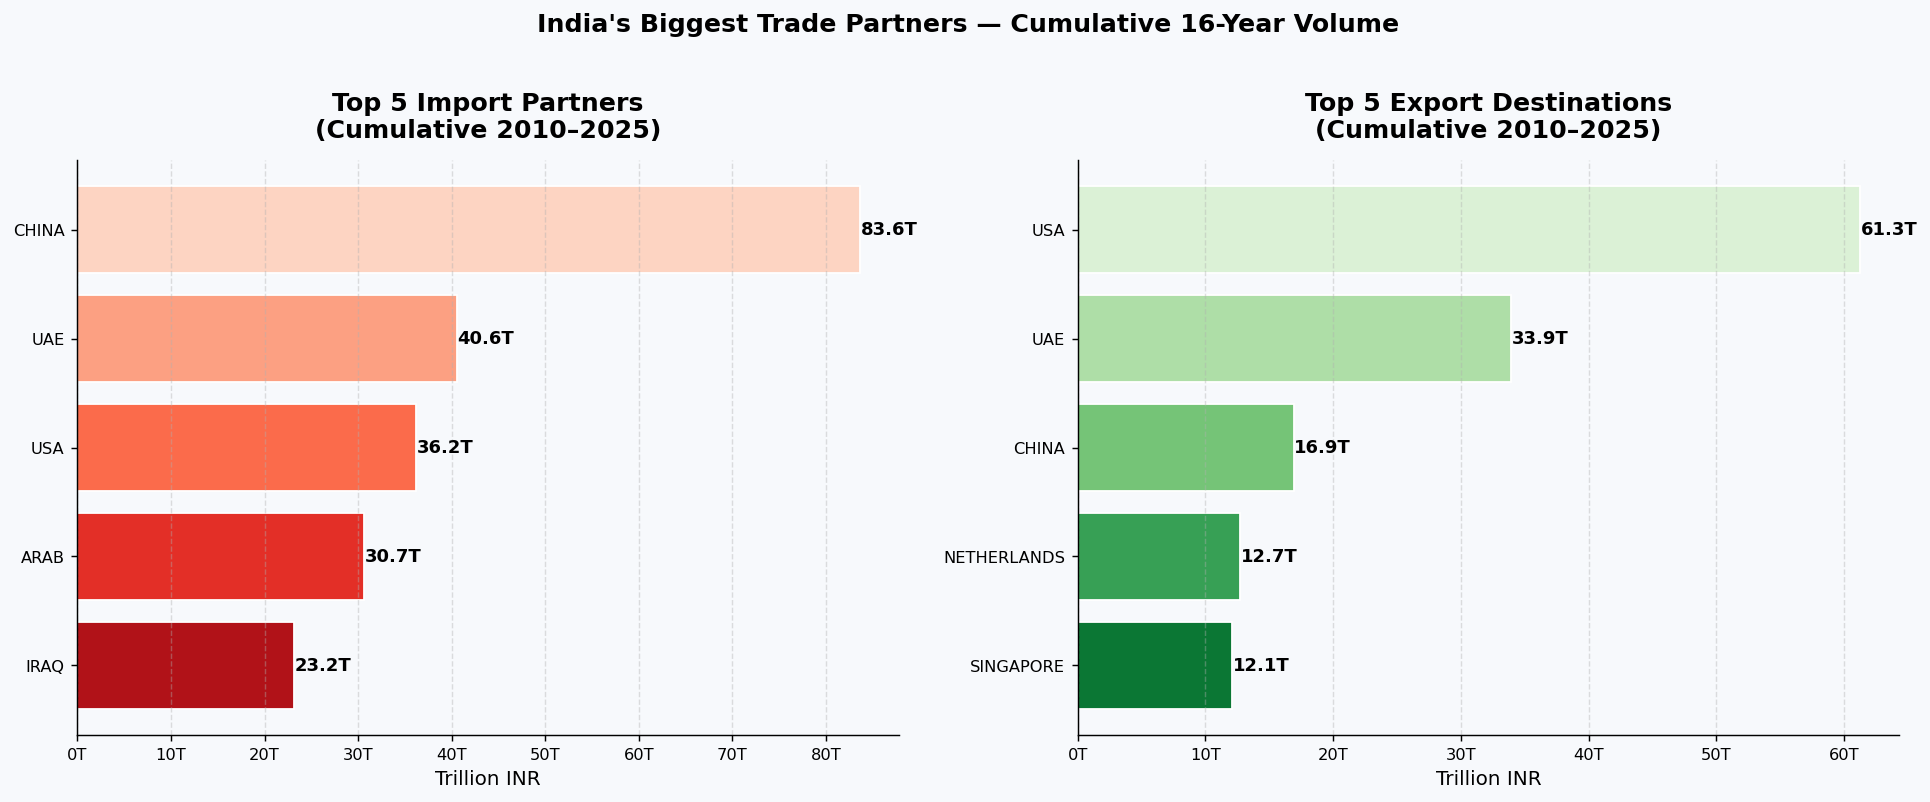


🔍 Conclusion: China is the undisputed import giant. On the export side, USA leads comfortably.
This asymmetry highlights India's need to diversify import sources and increase export competitiveness.


In [11]:
top5_imp = imp_T.sum().nlargest(5)
top5_exp = exp_T.sum().nlargest(5)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#f7f9fc')

# Import
ax = axes[0]
ax.set_facecolor('#f7f9fc')
bars = ax.barh(top5_imp.index[::-1], top5_imp.values[::-1],
               color=sns.color_palette('Reds_r', 5), edgecolor='white')
for bar, val in zip(bars, top5_imp.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}T', va='center', fontsize=10, fontweight='bold')
ax.set_title("Top 5 Import Partners\n(Cumulative 2010–2025)", pad=12)
ax.set_xlabel("Trillion INR")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}T'))
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Export
ax2 = axes[1]
ax2.set_facecolor('#f7f9fc')
bars2 = ax2.barh(top5_exp.index[::-1], top5_exp.values[::-1],
                 color=sns.color_palette('Greens_r', 5), edgecolor='white')
for bar, val in zip(bars2, top5_exp.values[::-1]):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}T', va='center', fontsize=10, fontweight='bold')
ax2.set_title("Top 5 Export Destinations\n(Cumulative 2010–2025)", pad=12)
ax2.set_xlabel("Trillion INR")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}T'))
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("India's Biggest Trade Partners — Cumulative 16-Year Volume",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot9_top5_comparative.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: China is the undisputed import giant. On the export side, USA leads comfortably.\nThis asymmetry highlights India's need to diversify import sources and increase export competitiveness.")

---
## 📊 Plot 10 — Outlier Detection: IQR Box Plots for Imports

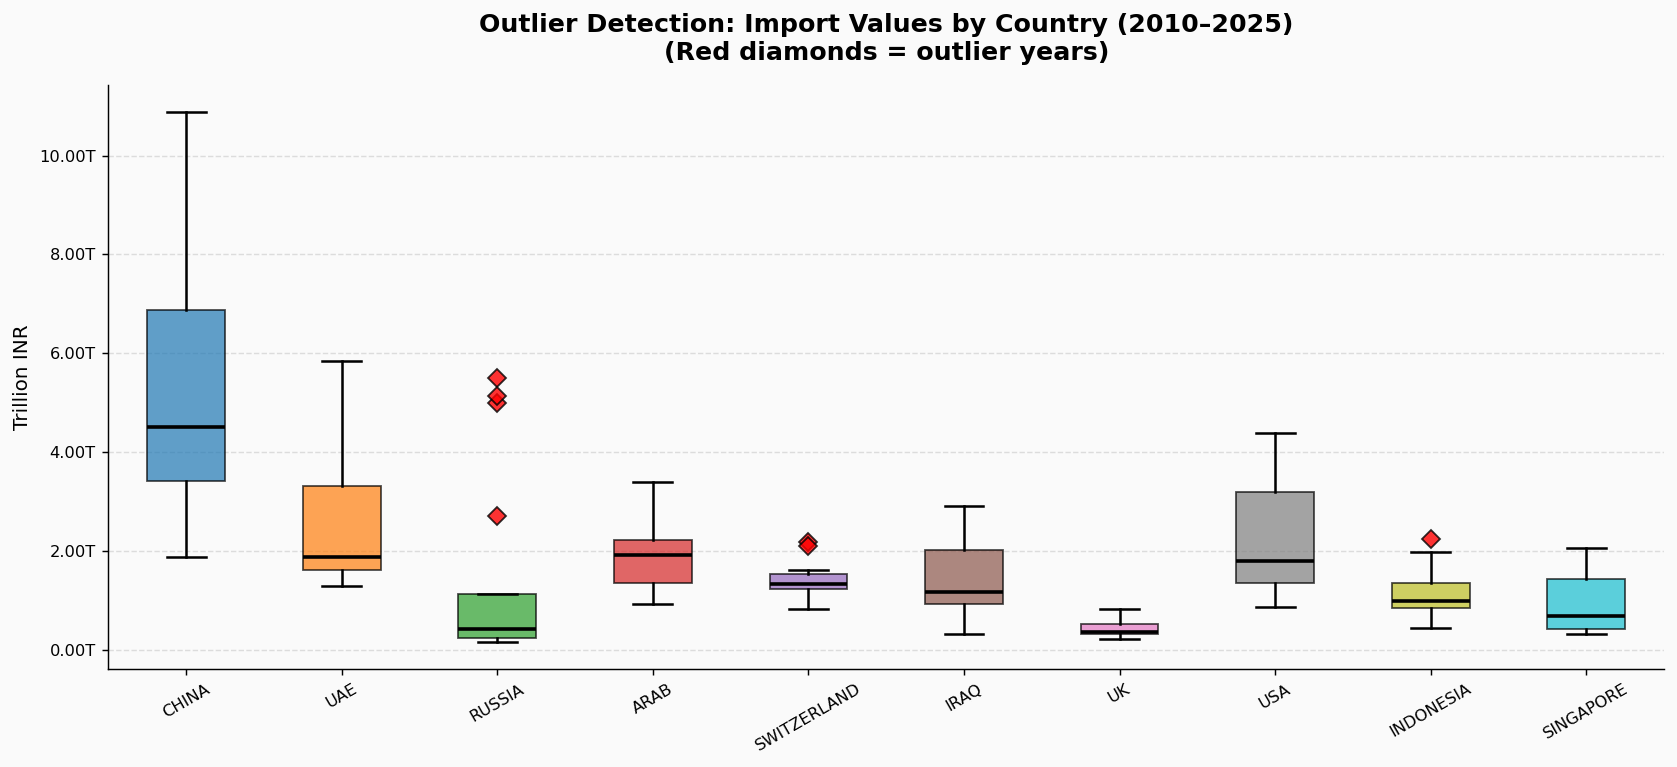


🔍 Outlier Detection Results:
  ⚠️  RUSSIA: Year 2022 = 2.712T (outlier)
  ⚠️  RUSSIA: Year 2023 = 5.003T (outlier)
  ⚠️  RUSSIA: Year 2024 = 5.496T (outlier)
  ⚠️  RUSSIA: Year 2025 = 5.148T (outlier)
  ⚠️  SWITZERLAND: Year 2021 = 2.180T (outlier)
  ⚠️  SWITZERLAND: Year 2024 = 2.108T (outlier)
  ⚠️  INDONESIA: Year 2022 = 2.247T (outlier)


In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

bp = ax.boxplot(
    [imp_T[c].values for c in import_countries],
    labels=import_countries, patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='D', markerfacecolor='red', markersize=7, alpha=0.8),
    whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4)
)
colors_box = sns.color_palette('tab10', 10)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Outlier Detection: Import Values by Country (2010–2025)\n(Red diamonds = outlier years)",
             pad=14)
ax.set_ylabel("Trillion INR")
ax.set_xticklabels(import_countries, rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}T'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot10_import_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Outlier Detection Results:")
for c in import_countries:
    q1, q3 = imp_T[c].quantile(0.25), imp_T[c].quantile(0.75)
    iqr = q3 - q1
    outliers = imp_T[c][(imp_T[c] < q1 - 1.5*iqr) | (imp_T[c] > q3 + 1.5*iqr)]
    if not outliers.empty:
        for yr, val in outliers.items():
            print(f"  ⚠️  {c}: Year {yr} = {val:.3f}T (outlier)")

---
## 📊 Plot 11 — Outlier Detection: IQR Box Plots for Exports

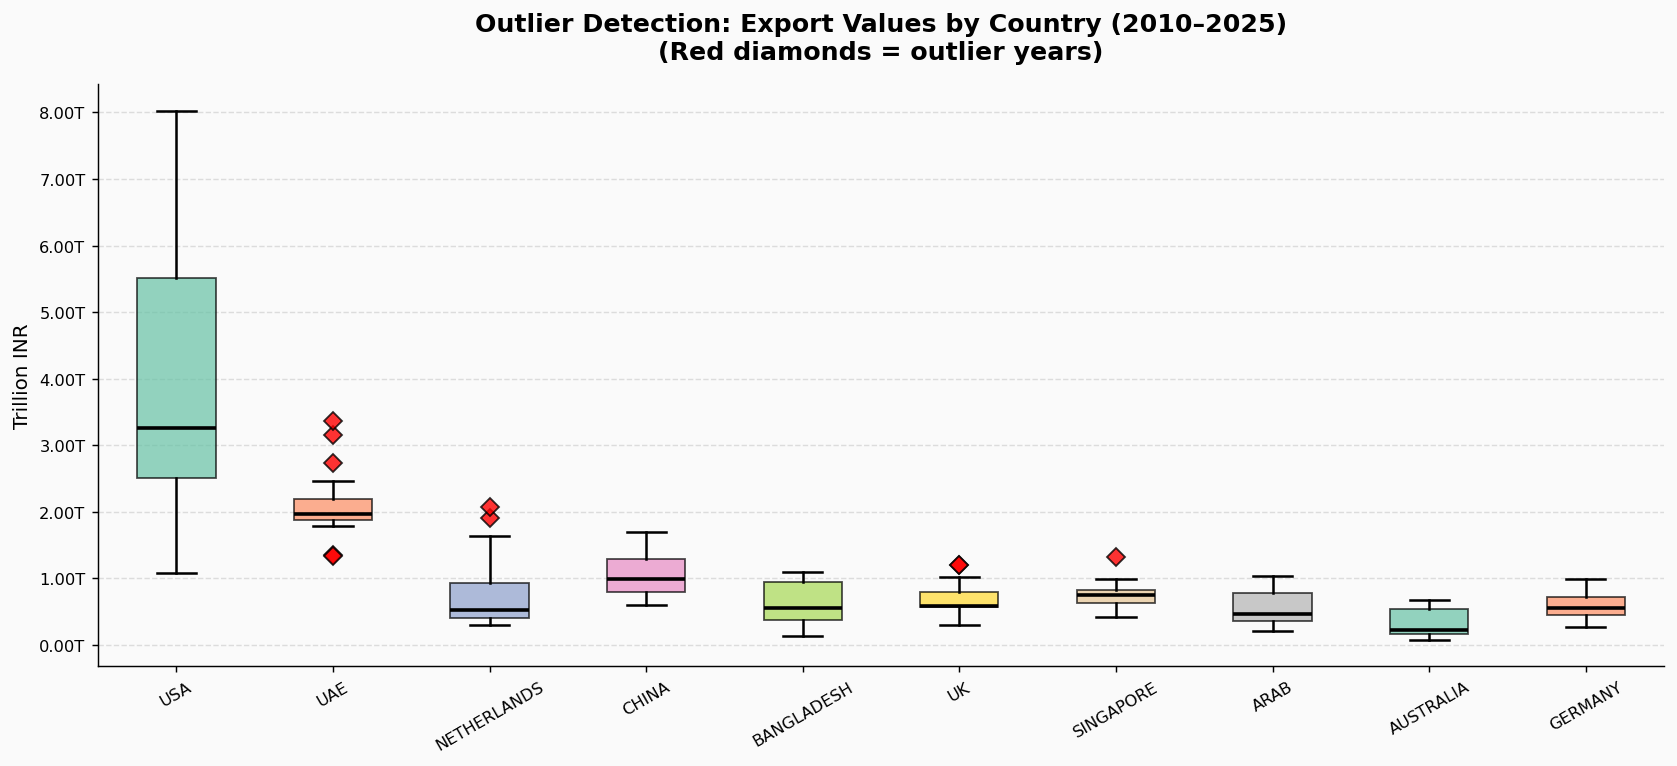


🔍 Outlier Detection Results:
  ⚠️  UAE: Year 2010 = 1.347T (outlier)
  ⚠️  UAE: Year 2020 = 1.329T (outlier)
  ⚠️  UAE: Year 2023 = 2.728T (outlier)
  ⚠️  UAE: Year 2024 = 3.161T (outlier)
  ⚠️  UAE: Year 2025 = 3.366T (outlier)
  ⚠️  NETHERLANDS: Year 2023 = 1.908T (outlier)
  ⚠️  NETHERLANDS: Year 2024 = 2.076T (outlier)
  ⚠️  UK: Year 2024 = 1.196T (outlier)
  ⚠️  UK: Year 2025 = 1.200T (outlier)
  ⚠️  SINGAPORE: Year 2024 = 1.328T (outlier)


In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

bp2 = ax.boxplot(
    [exp_T[c].values for c in export_countries],
    labels=export_countries, patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='D', markerfacecolor='red', markersize=7, alpha=0.8),
    whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4)
)
colors_box2 = sns.color_palette('Set2', 10)
for patch, color in zip(bp2['boxes'], colors_box2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Outlier Detection: Export Values by Country (2010–2025)\n(Red diamonds = outlier years)",
             pad=14)
ax.set_ylabel("Trillion INR")
ax.set_xticklabels(export_countries, rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}T'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot11_export_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Outlier Detection Results:")
for c in export_countries:
    q1, q3 = exp_T[c].quantile(0.25), exp_T[c].quantile(0.75)
    iqr = q3 - q1
    outliers = exp_T[c][(exp_T[c] < q1 - 1.5*iqr) | (exp_T[c] > q3 + 1.5*iqr)]
    if not outliers.empty:
        for yr, val in outliers.items():
            print(f"  ⚠️  {c}: Year {yr} = {val:.3f}T (outlier)")

---
## 📊 Plot 12 — Growth Rate: YoY Import Growth for China & Russia (Outlier Focus)

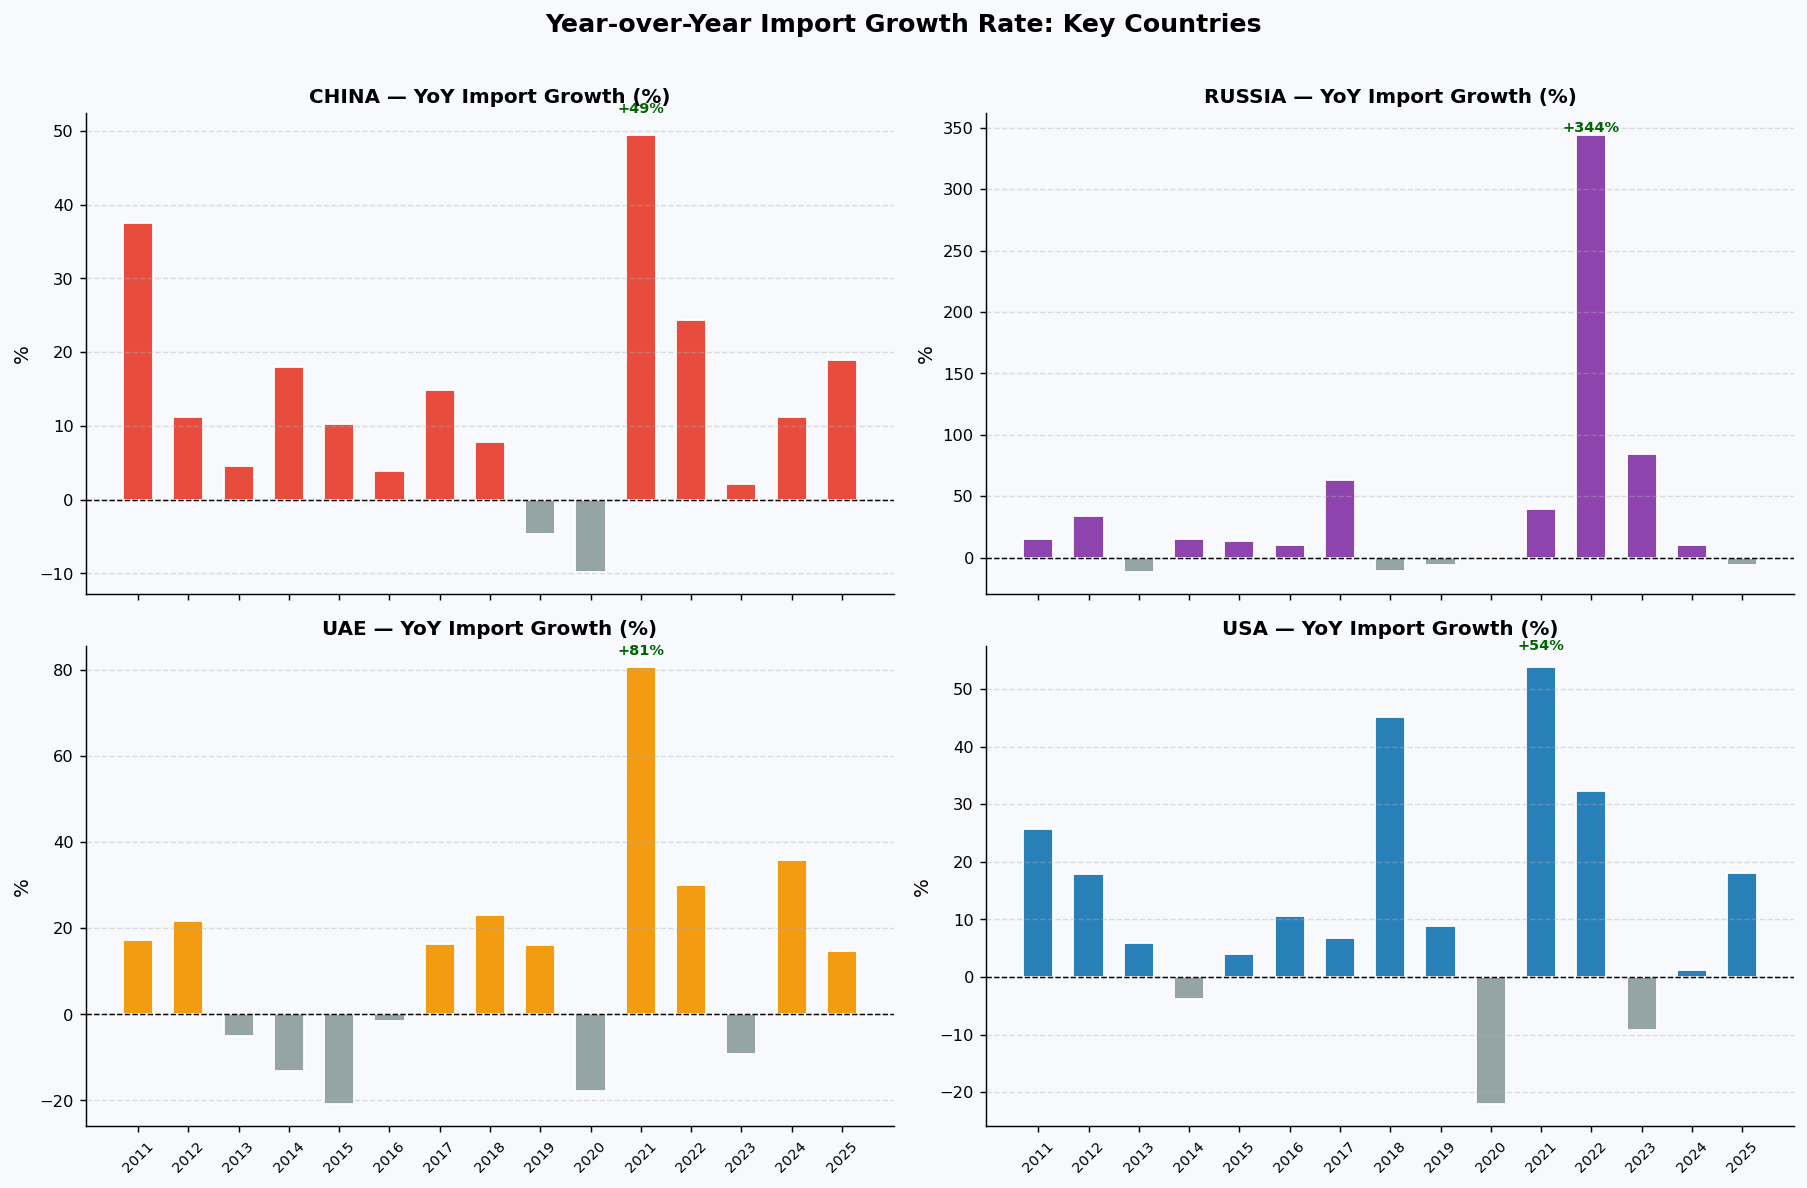


🔍 Conclusion: Russia shows extreme YoY growth in 2022 — likely due to India buying discounted Russian oil post-Ukraine sanctions.
China's import growth is more consistent, reflecting structural dependency. Both countries saw COVID-19 dip in 2020.


In [14]:
focus = ['CHINA', 'RUSSIA', 'UAE', 'USA']
imp_growth = imp_T[focus].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
fig.patch.set_facecolor('#f7f9fc')
palette = ['#e74c3c', '#8e44ad', '#f39c12', '#2980b9']

for ax, country, color in zip(axes.flat, focus, palette):
    ax.set_facecolor('#f7f9fc')
    vals = imp_growth[country].dropna()
    bars = ax.bar(vals.index, vals.values,
                  color=[color if v >= 0 else '#95a5a6' for v in vals.values],
                  edgecolor='white', width=0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f"{country} — YoY Import Growth (%)", fontsize=11)
    ax.set_ylabel("%")
    ax.set_xticks(vals.index)
    ax.set_xticklabels(vals.index, rotation=45, fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    # Annotate extreme spikes
    max_yr = vals.idxmax()
    ax.annotate(f'+{vals[max_yr]:.0f}%', xy=(max_yr, vals[max_yr]),
                xytext=(max_yr, vals[max_yr]+3),
                ha='center', fontsize=8, color='darkgreen', fontweight='bold')

fig.suptitle("Year-over-Year Import Growth Rate: Key Countries",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot12_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: Russia shows extreme YoY growth in 2022 — likely due to India buying discounted Russian oil post-Ukraine sanctions.\nChina's import growth is more consistent, reflecting structural dependency. Both countries saw COVID-19 dip in 2020.")

---
## 📊 Plot 13 — Area Chart: Cumulative Import + Export Trade Volume Over Time

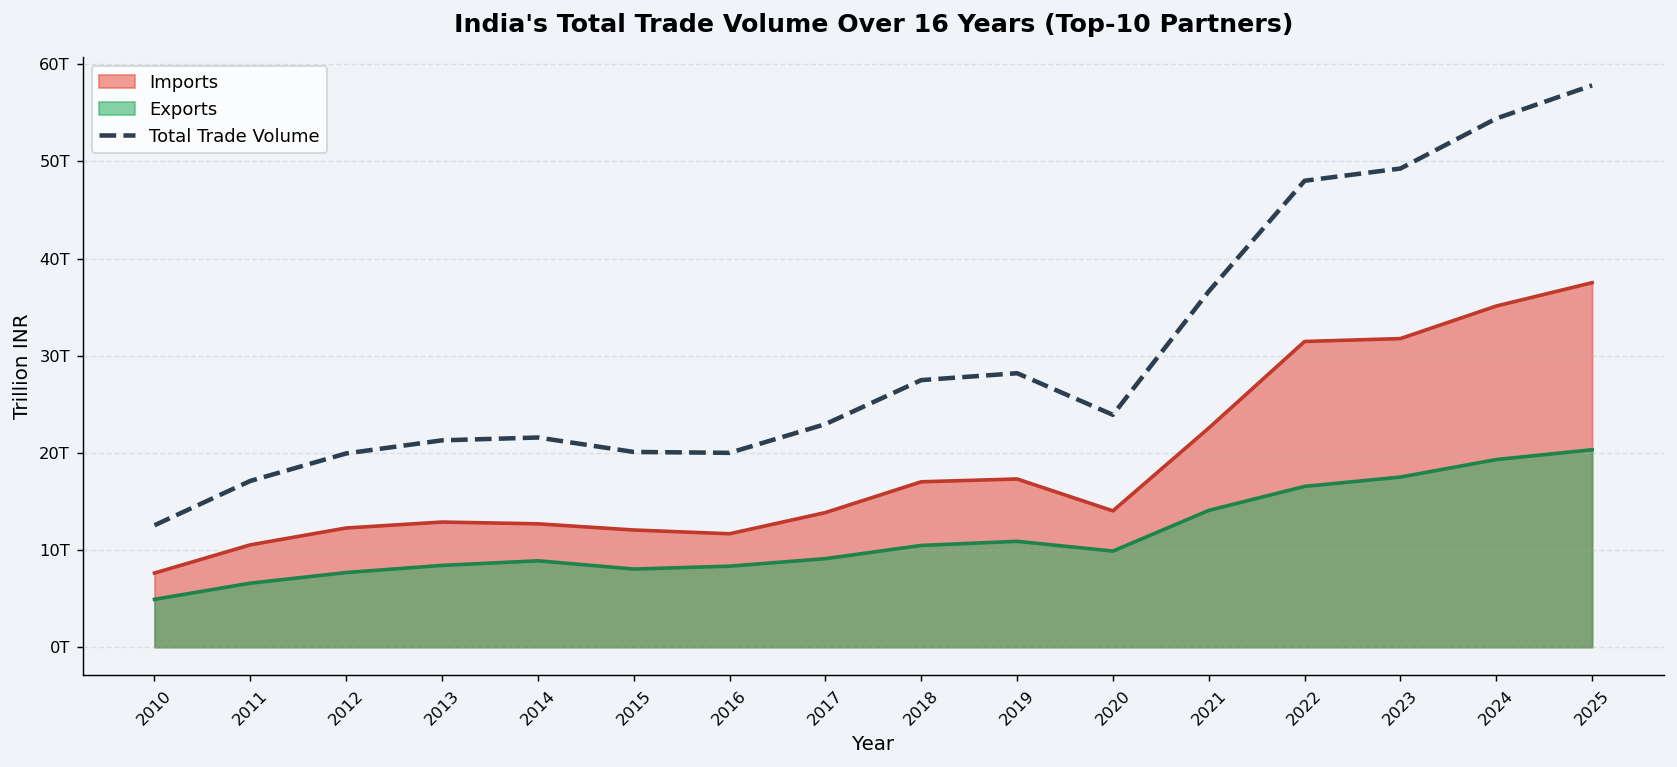


🔍 Conclusion: Total trade volume has grown ~3x from 2010 to 2025. The gap between imports and exports (trade deficit) has been widening, particularly after 2020. The dip in 2020 due to COVID-19 is clearly visible.


In [15]:
total_imp_yr = imp_T.sum(axis=1)
total_exp_yr = exp_T.sum(axis=1)
trade_vol = total_imp_yr + total_exp_yr

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#f0f4f9')
ax.set_facecolor('#f0f4f9')

ax.fill_between(years, 0, total_imp_yr.values, alpha=0.55, color='#e74c3c', label='Imports')
ax.fill_between(years, 0, total_exp_yr.values, alpha=0.55, color='#27ae60', label='Exports')
ax.plot(years, total_imp_yr.values, color='#c0392b', linewidth=2)
ax.plot(years, total_exp_yr.values, color='#1e8449', linewidth=2)
ax.plot(years, trade_vol.values, color='#2c3e50', linewidth=2.5,
        linestyle='--', label='Total Trade Volume')

ax.set_title("India's Total Trade Volume Over 16 Years (Top-10 Partners)", pad=14)
ax.set_ylabel("Trillion INR")
ax.set_xlabel("Year")
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}T'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plot13_area_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: Total trade volume has grown ~3x from 2010 to 2025. The gap between imports and exports (trade deficit) has been widening, particularly after 2020. The dip in 2020 due to COVID-19 is clearly visible.")

---
## 📊 Plot 14 — Radar Chart: Country-wise Trade Intensity (2025 snapshot)

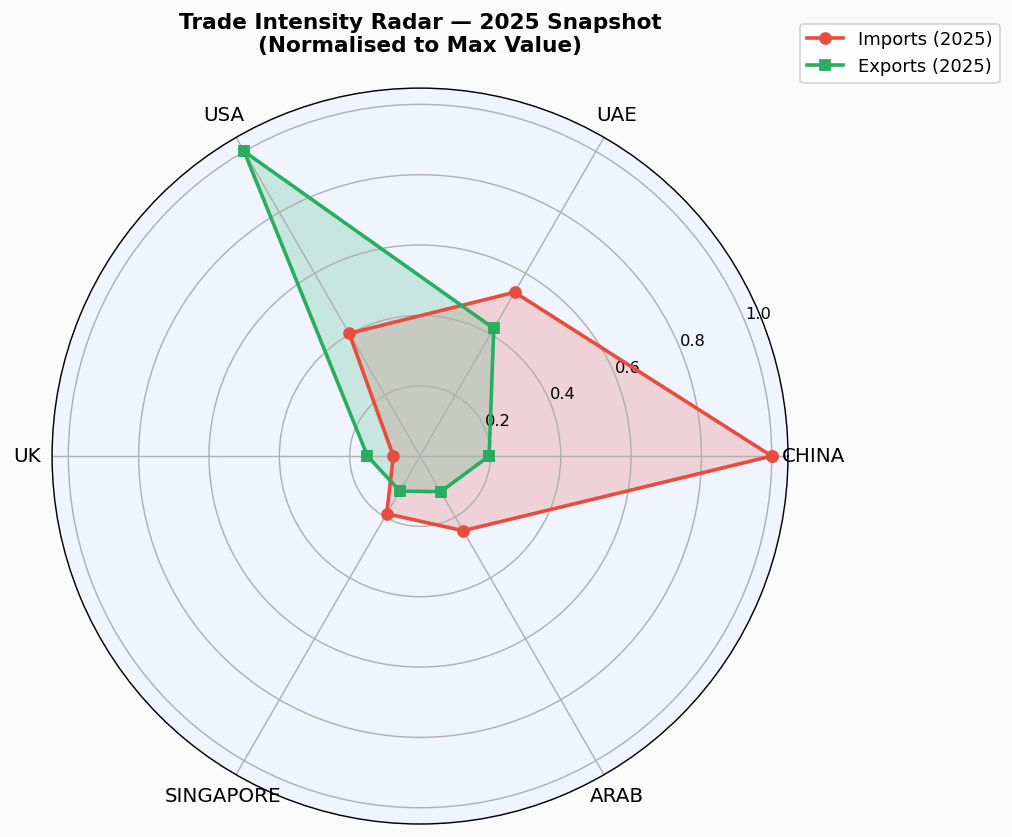


🔍 Conclusion: The radar chart shows that China is by far the most dominant import partner.
UAE is comparatively balanced. USA leads on the export side. The asymmetry for China is stark — India imports far more than it exports to China.


In [16]:
from matplotlib.patches import FancyArrowPatch

# Use 2025 (last year) data, normalise 0–1 for radar
imp_last = imp_T.iloc[-1]
exp_last_common = exp_T.iloc[-1]

# Select common countries
radar_countries = ['CHINA', 'UAE', 'USA', 'UK', 'SINGAPORE', 'ARAB']
imp_vals = np.array([imp_last[c] for c in radar_countries])
exp_vals = np.array([exp_last_common[c] for c in radar_countries])
imp_norm = imp_vals / imp_vals.max()
exp_norm = exp_vals / exp_vals.max()

N = len(radar_countries)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
imp_norm = np.append(imp_norm, imp_norm[0])
exp_norm = np.append(exp_norm, exp_norm[0])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#f0f4ff')

ax.plot(angles, imp_norm, 'o-', linewidth=2, color='#e74c3c', label='Imports (2025)')
ax.fill(angles, imp_norm, alpha=0.2, color='#e74c3c')
ax.plot(angles, exp_norm, 's-', linewidth=2, color='#27ae60', label='Exports (2025)')
ax.fill(angles, exp_norm, alpha=0.2, color='#27ae60')

ax.set_thetagrids(np.degrees(angles[:-1]), radar_countries, fontsize=11)
ax.set_title("Trade Intensity Radar — 2025 Snapshot\n(Normalised to Max Value)",
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('plot14_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: The radar chart shows that China is by far the most dominant import partner.\nUAE is comparatively balanced. USA leads on the export side. The asymmetry for China is stark — India imports far more than it exports to China.")

---
## 📊 Plot 15 — Trade Deficit Evolution: China vs USA (2010–2025)

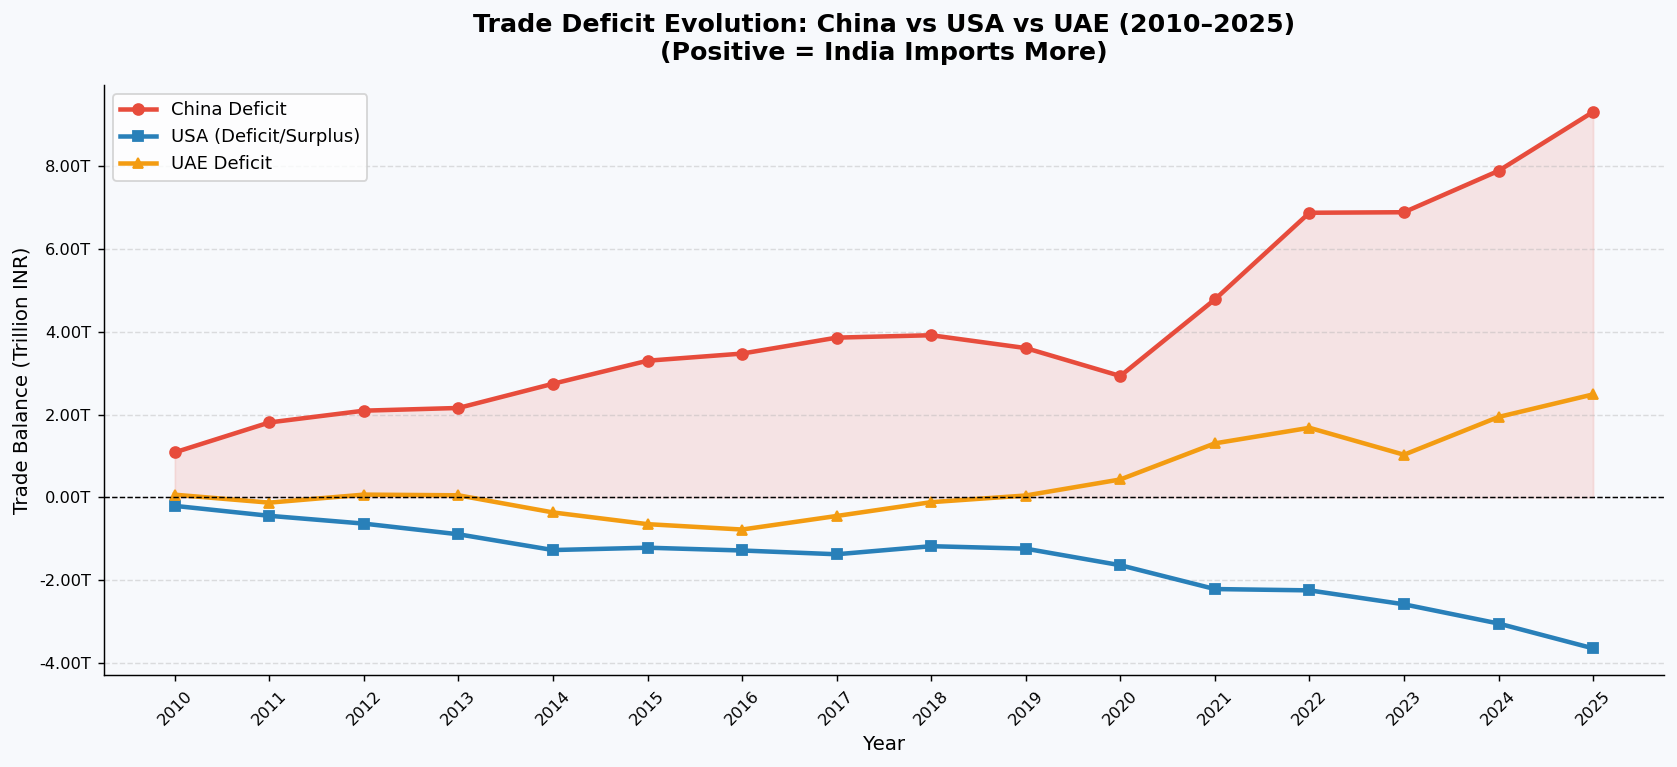


🔍 Conclusion: India's trade deficit with China has grown relentlessly and is the largest bilateral deficit.
With the USA, India has maintained a trade surplus (it exports more than it imports) — indicating strong demand for Indian goods in the US.
UAE shows a moderate, growing deficit mainly driven by energy imports.


In [18]:
china_deficit = imp_T['CHINA'] - exp_T['CHINA']
usa_deficit   = imp_T['USA']   - exp_T['USA']
uae_deficit   = imp_T['UAE']   - exp_T['UAE']

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#f7f9fc')
ax.set_facecolor('#f7f9fc')

ax.plot(years, china_deficit.values, 'o-', color='#e74c3c', linewidth=2.5, markersize=6, label='China Deficit')
ax.plot(years, usa_deficit.values,   's-', color='#2980b9', linewidth=2.5, markersize=6, label='USA (Deficit/Surplus)')
ax.plot(years, uae_deficit.values,   '^-', color='#f39c12', linewidth=2.5, markersize=6, label='UAE Deficit')

ax.fill_between(years, 0, china_deficit.values, where=[v > 0 for v in china_deficit], alpha=0.12, color='#e74c3c')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_title("Trade Deficit Evolution: China vs USA vs UAE (2010–2025)\n(Positive = India Imports More)", pad=14)
ax.set_ylabel("Trade Balance (Trillion INR)")
ax.set_xlabel("Year")
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}T'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('plot15_deficit_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔍 Conclusion: India's trade deficit with China has grown relentlessly and is the largest bilateral deficit.\nWith the USA, India has maintained a trade surplus (it exports more than it imports) — indicating strong demand for Indian goods in the US.\nUAE shows a moderate, growing deficit mainly driven by energy imports.")

---
## 📝 Final Summary of Key Conclusions


In [19]:
summary = """
╔══════════════════════════════════════════════════════════════════════════════╗
║         🇮🇳 INDIA TRADE ANALYSIS 2010–2025 — KEY CONCLUSIONS               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  1. CHINA DOMINANCE (Imports): China is India's #1 import source, growing   ║
║     from ~1.9T INR in 2010 to ~10.9T INR in 2025 — a ~6x increase.          ║
║     Trade deficit with China alone is the largest bilateral deficit India    ║
║     carries, raising strategic and economic concerns.                        ║
║                                                                              ║
║  2. USA TRADE SURPLUS: India maintains a trade surplus with the USA —        ║
║     exporting more than it imports. USA is India's #1 export destination.    ║
║                                                                              ║
║  3. RUSSIA OUTLIER (2022–2025): Russia imports spiked dramatically post-     ║
║     Ukraine war (2022) as India bought discounted Russian oil & gas.         ║
║     This is a clear statistical outlier in the 16-year trend.                ║
║                                                                              ║
║  4. COVID-19 IMPACT (2020): A visible dip in both imports and exports in     ║
║     2020, followed by a sharp recovery in 2021–22.                          ║
║                                                                              ║
║  5. UAE ROLE: UAE is significant in BOTH import and export baskets —         ║
║     acting as a re-export and trade hub. India imports oil; exports gold,    ║
║     gems, and textiles to UAE.                                               ║
║                                                                              ║
║  6. STRUCTURAL DEFICIT: India's total imports from top-10 partners           ║
║     consistently exceed exports, indicating a persistent structural trade    ║
║     deficit. This has widened post-2020 due to energy price inflation.       ║
║                                                                              ║
║  7. DIVERSIFICATION NEEDED: India's import concentration in China            ║
║     (~30%+ share) and energy nations is a risk. Policy efforts like PLI      ║
║     (Production Linked Incentive) schemes aim to reduce this dependency.     ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════════╗
║         🇮🇳 INDIA TRADE ANALYSIS 2010–2025 — KEY CONCLUSIONS               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  1. CHINA DOMINANCE (Imports): China is India's #1 import source, growing   ║
║     from ~1.9T INR in 2010 to ~10.9T INR in 2025 — a ~6x increase.          ║
║     Trade deficit with China alone is the largest bilateral deficit India    ║
║     carries, raising strategic and economic concerns.                        ║
║                                                                              ║
║  2. USA TRADE SURPLUS: India maintains a trade surplus with the USA —        ║
║     exporting more than it imports. USA is India's #1 export destination.    ║
║                                                                              ║
║  3. RUSSIA OUTLIER (2022–2025): Russia imports spiked dramatically post-     ║
║     Ukraine war (2022) as Indi